In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**1. LOAD AND CLEAN DATA**

In [5]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/shopify_stock.csv")
df.columns = df.columns.str.strip()
cols = ["open", "high", "low", "close", "volume"]
for col in cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df = df.dropna(subset=cols)
df = df.drop_duplicates()

***Convert Date if available***

In [6]:
if "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date")

**2. DAILY RETURNS**

In [9]:
df["Daily_Return"] = (
    (df["close"] - df["open"]) / df["open"]
) * 100

**3. OHLC PRICE AND VOLUME LINE PLOTS**

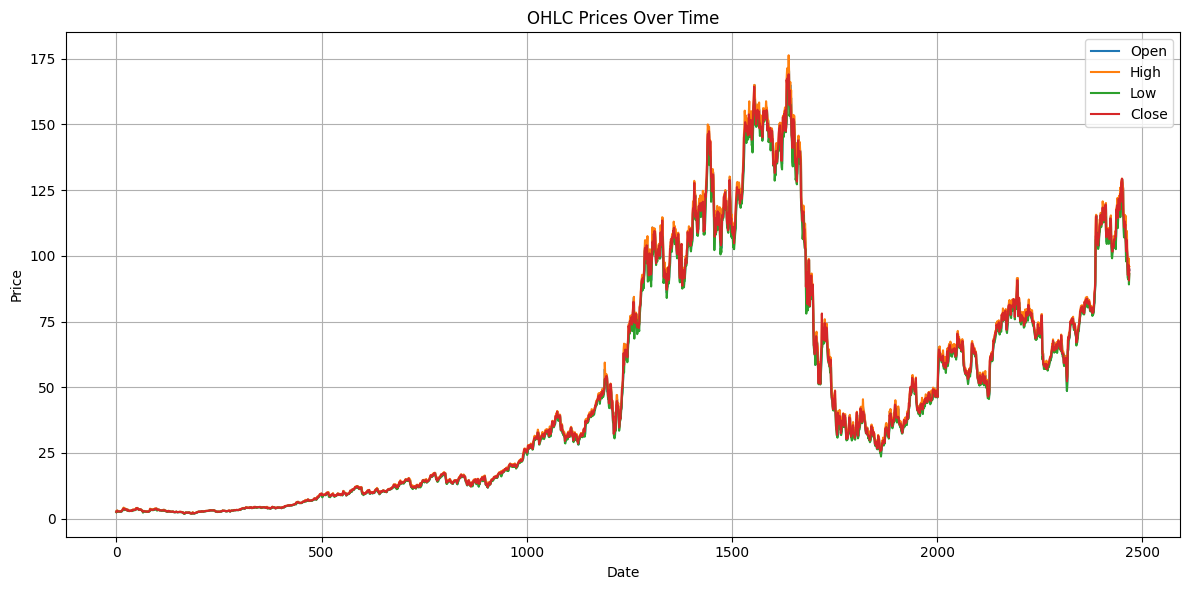

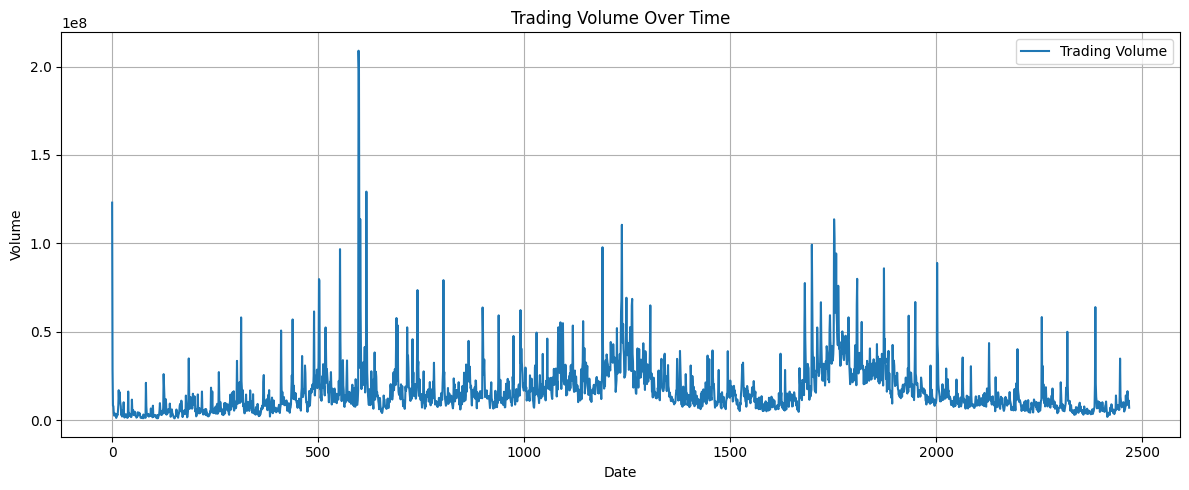

In [11]:
x = df["Date"] if "Date" in df.columns else df.index

plt.figure(figsize=(12, 6))

plt.plot(x, df["open"], label="Open")
plt.plot(x, df["high"], label="High")
plt.plot(x, df["low"], label="Low")
plt.plot(x, df["close"], label="Close")

plt.title("OHLC Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 5))

plt.plot(x, df["volume"], label="Trading Volume")

plt.title("Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**4. 20-DAY AND 50-DAY MOVING AVERAGES**

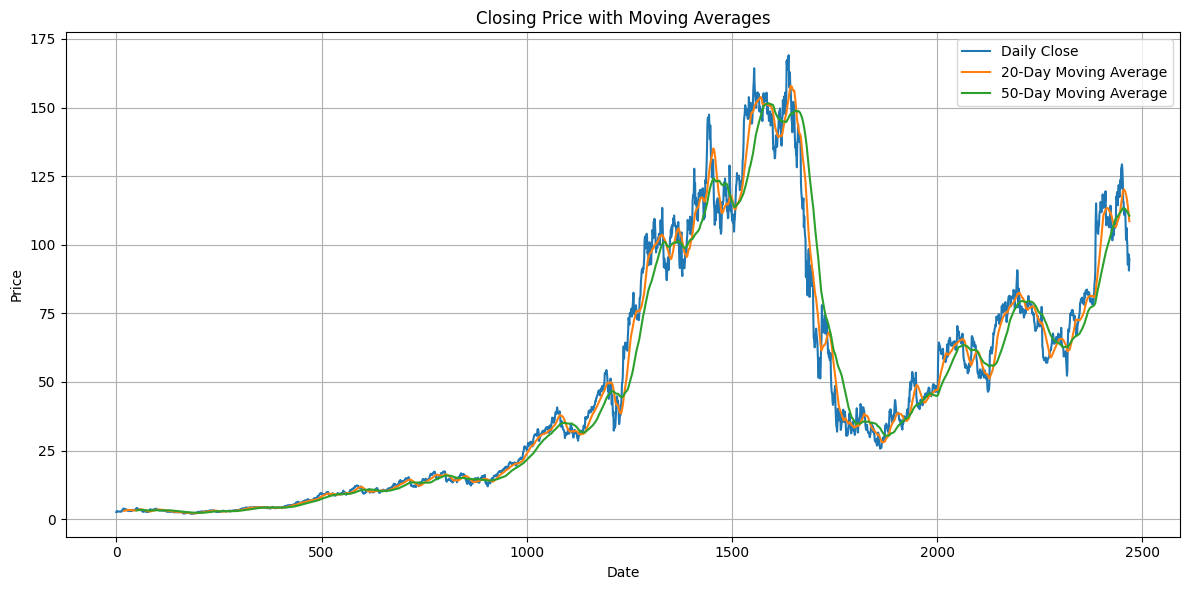

In [13]:
df["MA_20"] = df["close"].rolling(20).mean()
df["MA_50"] = df["close"].rolling(50).mean()

plt.figure(figsize=(12, 6))

plt.plot(x, df["close"], label="Daily Close")
plt.plot(x, df["MA_20"], label="20-Day Moving Average")
plt.plot(x, df["MA_50"], label="50-Day Moving Average")

plt.title("Closing Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**5. DAILY RETURN HISTOGRAM AND KDE**

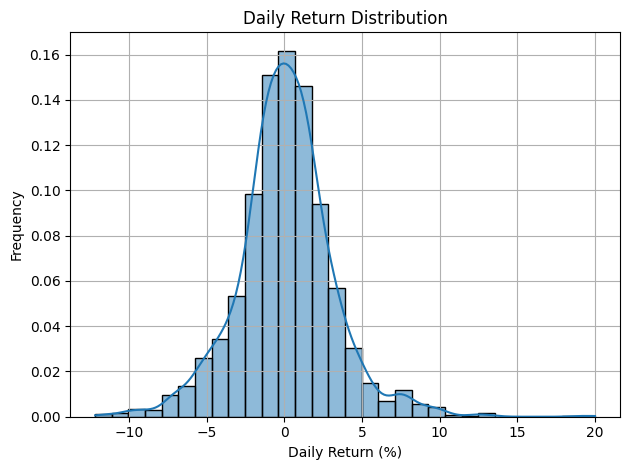

In [18]:
sns.histplot(
    df["Daily_Return"],
    bins=30,
    kde=True,
    stat="density"
)

plt.title("Daily Return Distribution")
plt.xlabel("Daily Return (%)")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()


**6. RETURN STATISTICS**

In [16]:
mean_return = df["Daily_Return"].mean()
variance_return = df["Daily_Return"].var()
std_return = df["Daily_Return"].std()

high_volatility = df[
    abs(df["Daily_Return"]) > 2 * std_return
]

print("\n========== FINANCIAL SUMMARY REPORT ==========")

print("\nReturn Statistics")
print("--------------------------------")
print("Mean Return          :", round(mean_return, 4), "%")
print("Variance             :", round(variance_return, 4))
print("Standard Deviation   :", round(std_return, 4), "%")

print("\nPrice Statistics")
print("--------------------------------")
print("Highest Closing Price:", df["close"].max())
print("Lowest Closing Price :", df["close"].min())

print("\nTrading Volume")
print("--------------------------------")
print("Average Volume       :", round(df["volume"].mean(), 2))
print("Maximum Volume       :", df["volume"].max())

print("\nHigh-Volatility Days")
print("--------------------------------")
print("Number of Days       :", len(high_volatility))

if len(high_volatility) > 0:
    print("\nHigh-Volatility Records:")
    print(
        high_volatility[
            ["open", "close", "Daily_Return", "volume"]
        ]
    )

print("\n========== INTERPRETATION ==========")

if std_return < 2:
    print("Stock Stability: Relatively stable returns.")
else:
    print("Stock Stability: Higher variation in daily returns.")

print(
    "High-volatility periods are identified using "
    "daily returns beyond ±2 standard deviations."
)


========== FINANCIAL SUMMARY REPORT ==========

Return Statistics
--------------------------------
Mean Return          : 0.0864 %
Variance             : 9.7331
Standard Deviation   : 3.1198 %

Price Statistics
--------------------------------
Highest Closing Price: 169.05999755859375
Lowest Closing Price : 1.932999968528748

Trading Volume
--------------------------------
Average Volume       : 16570491.78
Maximum Volume       : 208959000

High-Volatility Days
--------------------------------
Number of Days       : 146

High-Volatility Records:
            open       close  Daily_Return     volume
0       2.800000    2.568000     -8.285710  123039000
1       2.607000    2.831000      8.592250   28412000
3       3.067000    2.750000    -10.335830    7976000
12      2.664000    2.834000      6.381384    3375000
14      2.849000    3.073000      7.862407    4606000
...          ...         ...           ...        ...
2387  107.500000  115.089996      7.060462   20642000
2411  118.80500